# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [1]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from shapely.wkt import loads
from shapely.ops import unary_union

from src.eda import (COLORS, COLORS_DICT, get_parks_data, groupby_multipoly,
                     PARKS_MAPPING, nymyc_cmap, nymyc_cmap_r, read_all_csvs,
                     remove_unknown_sp)

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

<Axes: >

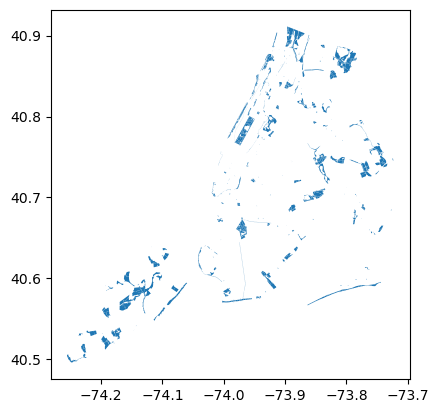

In [2]:
parks = gpd.read_file('../data/Parks Zones_20241027/', crs='epsg:4326', geometry='geometry')
parks.plot()

<Axes: >

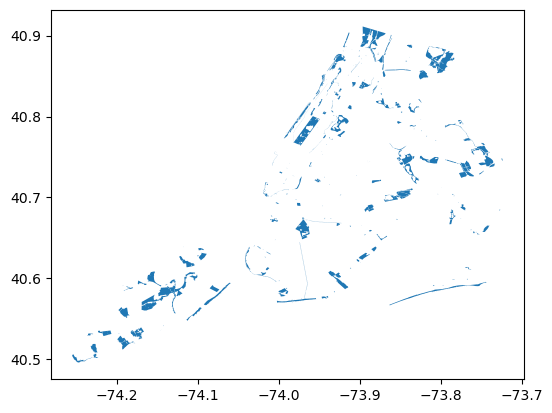

In [3]:
# https://stackoverflow.com/questions/73803944/convert-polygon-to-multi-polygon
# Need to do this to match the Multipolygons for Green-wood and Woodlawn Cemeteries
parks = parks.groupby(['propname','borough'], as_index=False)['geometry'].apply(unary_union)
parks.plot()

Got it plotting! But definitely need borough boundaries or something else in the background--can't just have parks floating in space.

<Axes: >

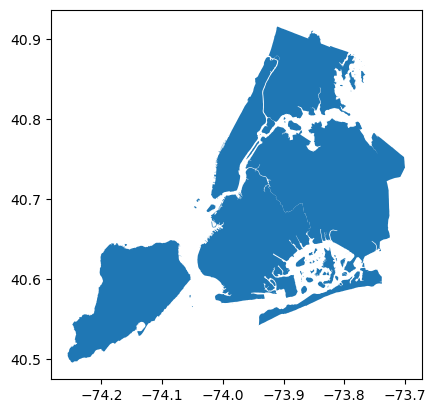

In [4]:
boroughs = gpd.read_file('../data/Borough Boundaries/')
boroughs.plot()

Now to combine them...

<Axes: >

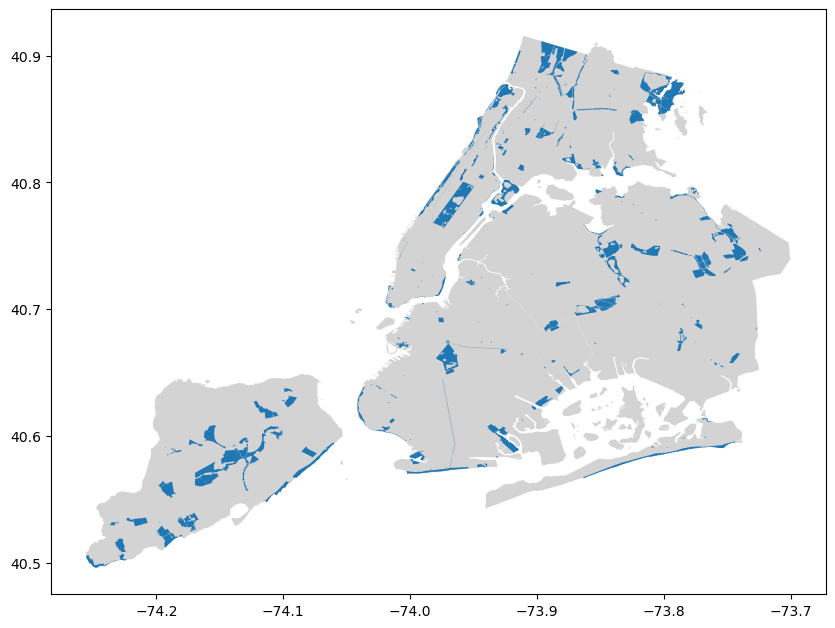

In [5]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Need to add in Green-Wood and Woodlawn Cemeteries.

In [6]:
cemeteries = pd.read_csv('../data/2020_Neighborhood_Tabulation_Areas__NTAs__20241127.csv')
cemeteries['the_geom'] = cemeteries['the_geom'].apply(loads)
cemeteries = gpd.GeoDataFrame(cemeteries, crs='epsg:4326', geometry='the_geom')
cemeteries = cemeteries.loc[(cemeteries['NTAName'] == 'Green-Wood Cemetery') | (cemeteries['NTAName'] == 'Woodlawn Cemetery')][['the_geom','BoroName','NTAName']]
cemeteries

,the_geom,BoroName,NTAName
25,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ...",Brooklyn,Green-Wood Cemetery
114,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ...",Bronx,Woodlawn Cemetery


In [7]:
# Prep cemeteries data to append to parks data
cemeteries['BoroName'] = cemeteries['BoroName'].map({v: k for k, v in PARKS_MAPPING.items()})
cemeteries = cemeteries.rename(columns={'BoroName':'borough', 'NTAName':'propname','the_geom':'geometry'})
cemeteries

,geometry,borough,propname
25,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ...",B,Green-Wood Cemetery
114,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ...",X,Woodlawn Cemetery


In [8]:
all_parks = pd.concat([parks,cemeteries]).reset_index()
all_parks.tail()

,index,propname,borough,geometry
186,186,Washington's Walk,X,"MULTIPOLYGON (((-73.89832 40.87172, -73.89832 ..."
187,187,Williamsbridge Oval,X,"MULTIPOLYGON (((-73.87732 40.87671, -73.87734 ..."
188,188,Wolfe's Pond Park,R,"MULTIPOLYGON (((-74.18665 40.51804, -74.18665 ..."
189,25,Green-Wood Cemetery,B,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ..."
190,114,Woodlawn Cemetery,X,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ..."


Success! Now to get some data in there...

In [9]:
parks_data = get_parks_data()
parks_data.head()

,MushroomID,NewToPark,NewToCity,ParkName,Borough,City,State,BroadGroupID,Genus,Species,BroadGroupName,FullName
0,300,y,y,Central Park,Manhattan,New York City,NY,3.0,Hortiboletus,campestris,Boletes,Hortiboletus campestris
1,2329,y,y,Central Park,Manhattan,New York City,NY,3.0,Boletus,subvelutipes-complex,Boletes,Boletus subvelutipes-complex
2,3,y,y,Central Park,Manhattan,New York City,NY,3.0,Cyanoboletus,pulverulentus,Boletes,Cyanoboletus pulverulentus
3,4,y,y,Central Park,Manhattan,New York City,NY,3.0,Gyroporus,castaneus,Boletes,Gyroporus castaneus
4,5,y,y,Central Park,Manhattan,New York City,NY,3.0,Tylopilus,ferrugineus,Boletes,Tylopilus ferrugineus


In [13]:
# Check for parks that don't match across datasets
nymyc_parks = list(parks_data['ParkName'].unique())
nymyc_parks.sort()
nyc_parks = list(parks['propname'].unique())
nyc_parks.sort()
print('Parks in walks list but not in NYC data:')
print([p for p in nymyc_parks if p not in nyc_parks])
print('\n')
print('Parks in NYC data but not in walks list:')
print([p for p in nyc_parks if p not in nymyc_parks])

Parks in walks list but not in NYC data:
['Beech Brook', 'Collis P. Huntingdon Park', 'Depew Park', "Devil's Den Preserve", 'Fahnestock State Park', 'Green-Wood Cemetery', 'High Rock Park', 'Manitou Point Preserve', 'Mt. Lakes Park', 'Norvin Green State Forest', 'Putnam Memorial State Park', 'South Mountain Reservation', 'Stony Brook, Harriman', 'Stony Brook, Long Island', 'Tallman State Park', 'Untermeyer Gardens', 'Wawayanda State Park', 'Woodlawn Cemetery']


Parks in NYC data but not in walks list:
['Alley Athletic Playground', 'Aqueduct Walk', 'Archie Spigner Park', 'Arden Woods', 'Asphalt Green', 'Asser Levy Park', 'Astoria Park', 'Bailey Playground', 'Baisley Pond Park', 'Battery Park City', 'Bayswater Park', 'Belt Parkway/Shore Parkway', 'Bensonhurst Park', 'Betsy Head Park', 'Blood Root Valley', 'Bloomingdale Park', 'Blue Heron Park', 'Bowne Park', 'Breukelen Ballfields', 'Broadway Malls', 'Bronx Park', 'Bronx River Parkway', 'Brookfield Park', 'Brooklyn Bridge Park', 'Brookvi

Looks like most of the parks from the walk list that aren't in NYC's data are, in fact, not in NYC. So no worries there. Others aren't NYC parks, like Woodlawn Cemetery.

The parks in NYC's data that aren't in the walks list are a lot of parks that just don't have walks (like Washington Sq Park).

There are some that just don't match up (like 'Randalls Island' vs 'Randall's Island Park' and 'Wolfe\\'s Pond Park' vs 'Wolfe's Pond Park'), so should clean those up. (Note: adding that to some of the cleaning functinality in `eda.py` that gets called whenever reading in the data.)

In [23]:
parks_counts = parks_data.groupby('ParkName')[['BroadGroupName','Species']].nunique().reset_index()
parks_counts = parks_counts.rename(columns={'BroadGroupName':'BroadGroupCounts',
                                            'Species':'SpeciesCounts'})
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts
0,Alley Pond Park,16,381
1,Beech Brook,17,386
2,Central Park,14,316
3,Clove Lakes Park,15,302
4,Collis P. Huntingdon Park,14,246
5,Conference House Park,2,2
6,Cunningham Park,15,364
7,Depew Park,12,185
8,Devil's Den Preserve,11,128
9,Fahnestock State Park,13,159


In [26]:
parks_viz = parks.merge(parks_counts, left_on='propname', right_on='ParkName', how='left')
# Drop non-NYC parks (no SpeciesCounts)
parks_viz = parks_viz.dropna(subset='SpeciesCounts')
parks_viz.head()

,propname,borough,geometry,ParkName,BroadGroupCounts,SpeciesCounts
1,Alley Pond Park,Q,"MULTIPOLYGON (((-73.73349 40.74083, -73.73350 ...",Alley Pond Park,16.0,381.0
32,Central Park,M,"MULTIPOLYGON (((-73.97354 40.76377, -73.97354 ...",Central Park,14.0,316.0
34,Clove Lakes Park,R,"MULTIPOLYGON (((-74.10576 40.61868, -74.10571 ...",Clove Lakes Park,15.0,302.0
39,Conference House Park,R,"MULTIPOLYGON (((-74.25035 40.49756, -74.25038 ...",Conference House Park,2.0,2.0
46,Cunningham Park,Q,"MULTIPOLYGON (((-73.77509 40.72521, -73.77513 ...",Cunningham Park,15.0,364.0


In [27]:
parks_viz.shape

(15, 6)

''

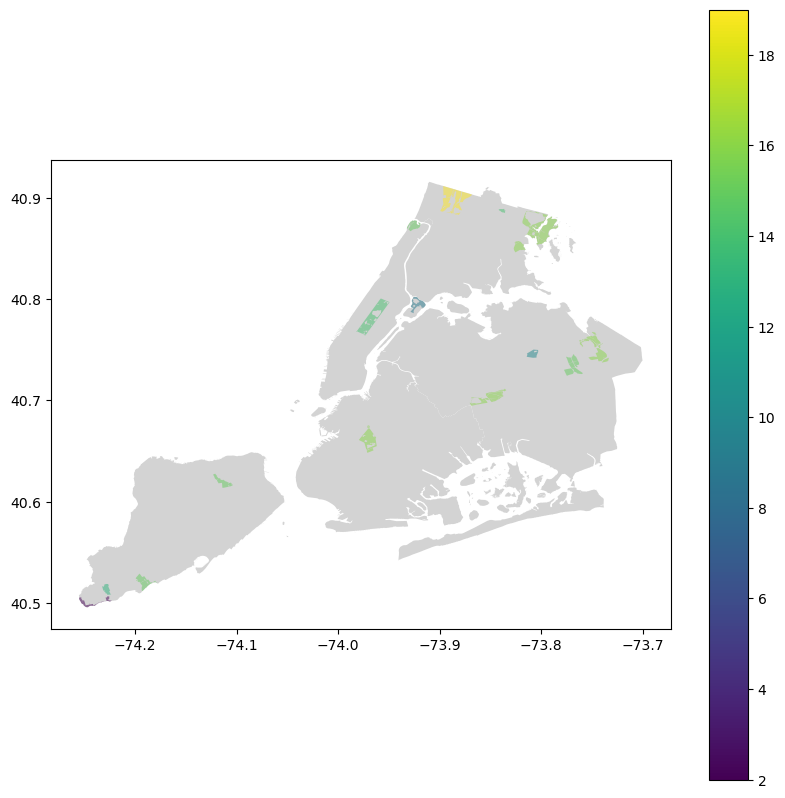

In [28]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='BroadGroupCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_groups_counts.png')
;

''

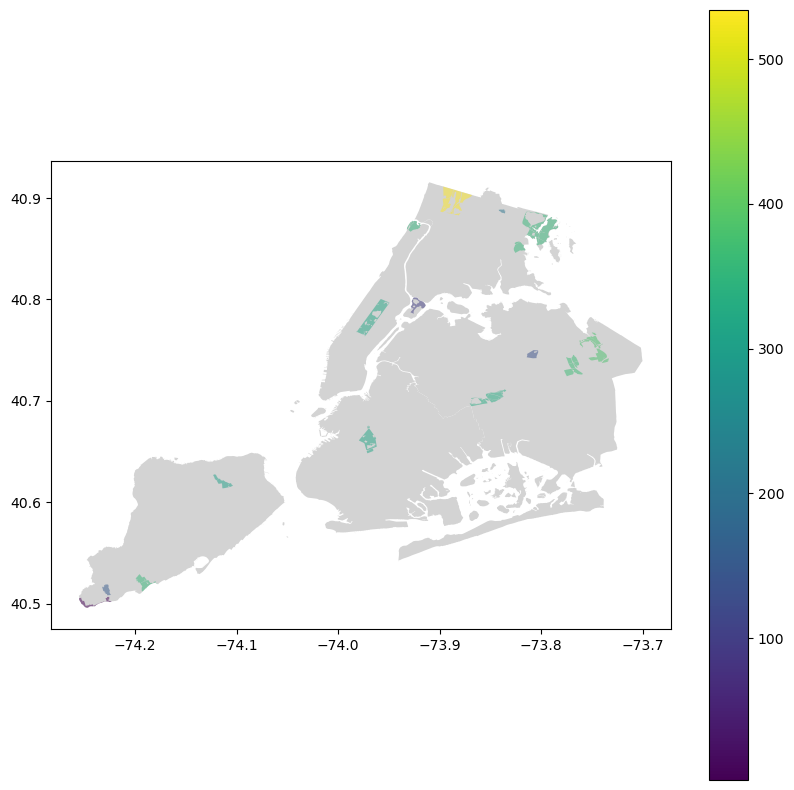

In [29]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
plt.savefig('./img/parks_species_counts.png')
;

Let's try visualizing each park separately to get better resolution.

''

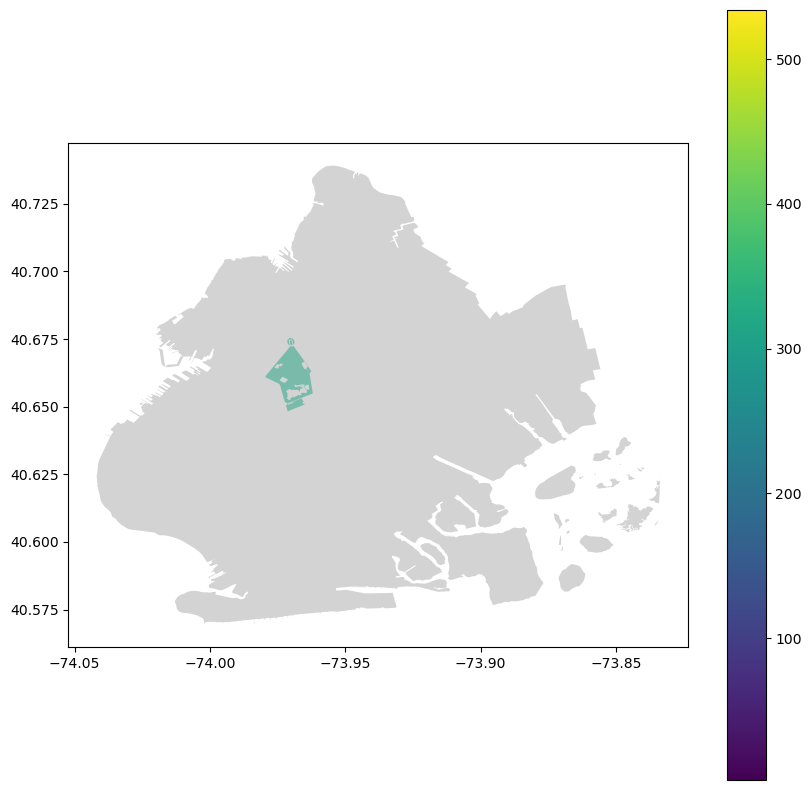

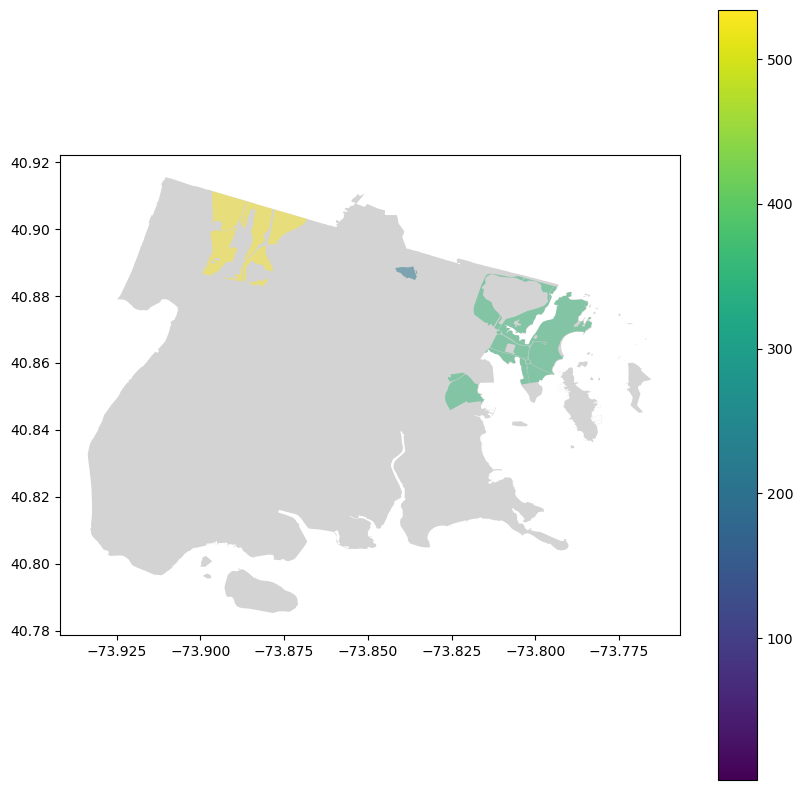

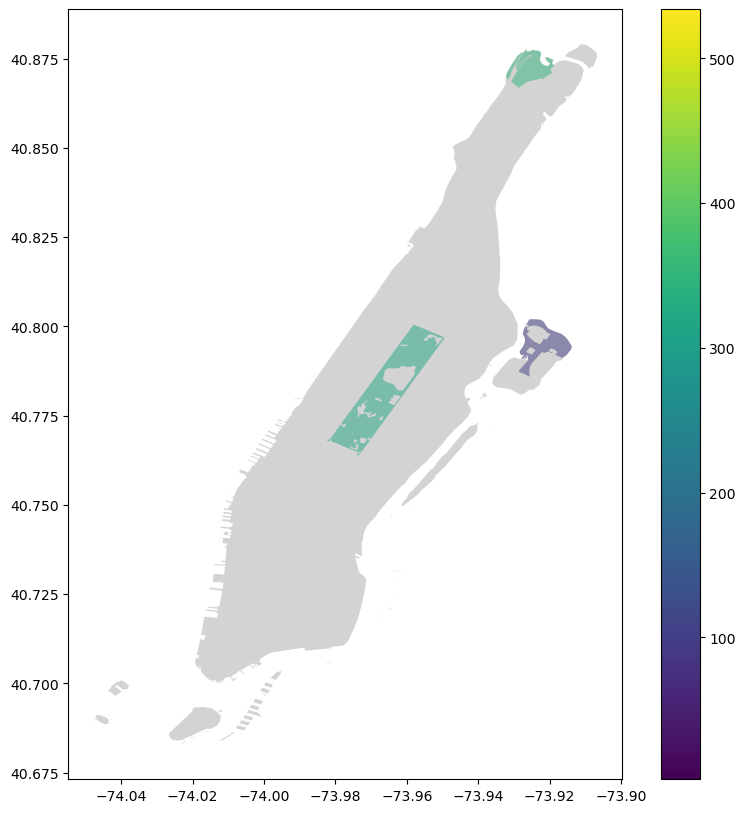

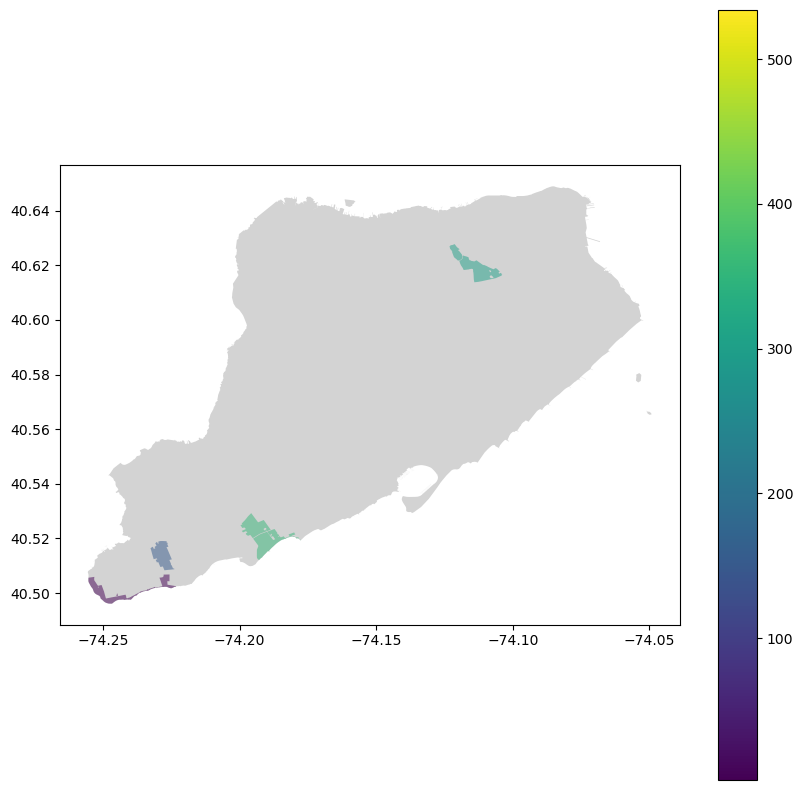

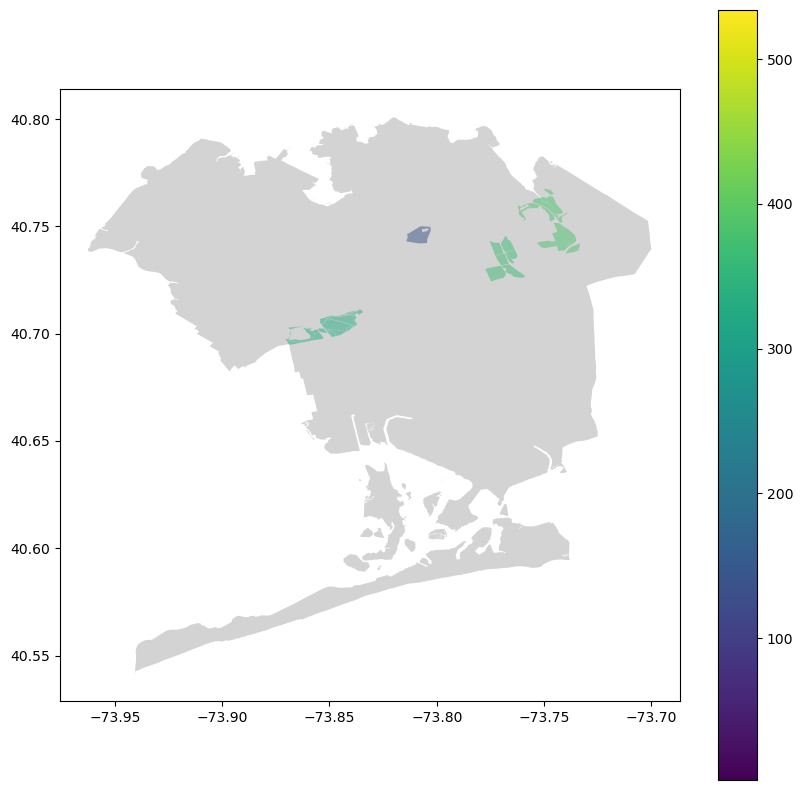

In [30]:
for b, boro in PARKS_MAPPING.items():
    fig, ax = plt.subplots(figsize=(10,10))
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax, legend=True, 
                                                alpha=.5, vmin=parks_viz['SpeciesCounts'].min(),
                                                vmax=parks_viz['SpeciesCounts'].max())
    # print(ax._children[1].__dict__)
    # print(ax.__dict__)
    # print(dir(ax))
;

''

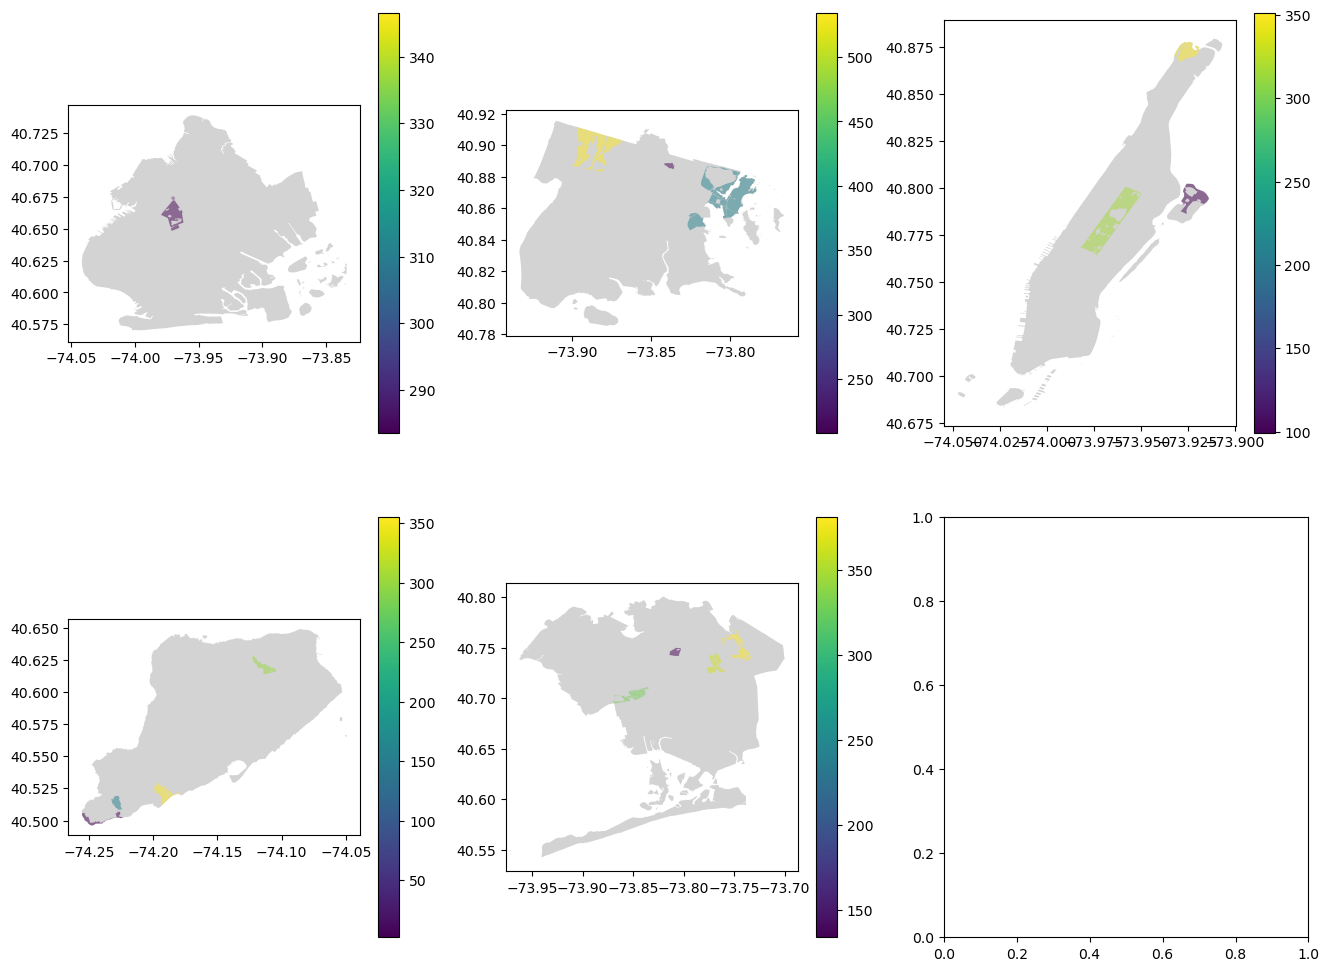

In [31]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax,
                  legend=True, alpha=.5)
;

In [32]:
boroughs.loc[boroughs['boro_name']=='Brooklyn']

,boro_code,boro_name,shape_area,shape_leng,geometry
0,3.0,Brooklyn,1.934143e+09,728147.130565,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."


## Normalizing the data

Showing the number of species per park isn't super helpful since some parks are visited far more often than others. Let's try plotting the number of species *per walk*.

In [26]:
dfs = read_all_csvs('./data')
print(dfs.keys())

[*] Reading in Parks.csv...
[*] Reading in BroadGroups.csv...
[*] Reading in Parks_Properties_20241008.csv...
[*] Reading in 2020_Neighborhood_Tabulation_Areas__NTAs__20241127.csv...
[*] Reading in Mushroom.csv...
[*] Reading in Walks.csv...
[*] Reading in Observations.csv...
dict_keys(['parks', 'broadgroups', 'parks_properties_20241008', '2020_neighborhood_tabulation_areas__ntas__20241127', 'mushroom', 'walks', 'observations'])


In [61]:
# Are there walks where species are repeated in the observations?
walk_id_counts = dfs['observations'].groupby('WalkID').agg({'MushroomID':['count','nunique']})
walk_id_counts.columns = walk_id_counts.columns.droplevel(0)
print('Counts != N Unique:')
print(len(walk_id_counts.loc[walk_id_counts['count']!=walk_id_counts['nunique']]))
print('\nCounts == N Unique')
print(len(walk_id_counts.loc[walk_id_counts['count']==walk_id_counts['nunique']]))

Counts != N Unique:
273

Counts == N Unique
264


In [66]:
walk_id_counts['diff'] = walk_id_counts['count'] - walk_id_counts['nunique']
max(walk_id_counts['diff'])

9

In [67]:
walk_id_counts.loc[walk_id_counts['diff']==9]

,count,nunique,diff
WalkID,,,
140,66,57,9


In [68]:
dfs['observations'].loc[dfs['observations']['WalkID']==140]

,ObservationID,MushroomID,WalkID,ParkID,NewToPark,NewToCity,Notes,LinkToINat,DateCreated,DateModified
5527,5956,228,140,19,NaN,NaN,as Daldinia concentrica,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5528,5957,168,140,19,NaN,NaN,NaN,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5529,5958,326,140,19,NaN,NaN,NaN,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5530,5959,171,140,19,NaN,NaN,Hypoxylon cf. multiforme,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5531,5960,171,140,19,NaN,NaN,spp,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
...,...,...,...,...,...,...,...,...,...,...
5588,6018,41,140,19,NaN,NaN,NaN,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5589,6019,940,140,19,NaN,NaN,Various resupinate polypores,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5590,6020,940,140,19,NaN,NaN,"poroid, fuzzy, yellow-brown surrounding",NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
5591,6021,940,140,19,NaN,NaN,"poroid, off-white, refracting light",NaN,2023-12-10 17:04:22,2023-12-10 17:04:22


In [81]:
mushrooms = pd.read_csv('../data/Mushroom.csv')
mushrooms.loc[mushrooms['MushroomID']==940]

,MushroomID,BroadGroupID,Genus,Species,WhyOrWhyNot,DateCreated,DateModified
584,940,12,Unknown,sp.,wrong group,2020-05-04 20:35:18,2021-06-16 18:45:20


In [75]:
dfs['observations'].loc[dfs['observations']['MushroomID']==940]

,ObservationID,MushroomID,WalkID,ParkID,NewToPark,NewToCity,Notes,LinkToINat,DateCreated,DateModified
1247,1253,940,25,20,y,y,Resupinate poroid fungi (several),NaN,2023-12-11 16:39:33,2023-12-11 16:39:33
1378,1387,940,28,13,y,NaN,A dark brown poroid resupinate,NaN,2023-12-11 16:39:34,2023-12-11 16:39:34
1379,1388,940,28,13,NaN,NaN,A white poroid resupinate,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
1614,1626,940,33,26,y,NaN,"white, centrally stipitate, fleshy-firm",NaN,2023-12-11 16:39:36,2023-12-11 16:39:36
1615,1627,940,33,26,NaN,NaN,not Inonotus dryadeus (but resembles it),NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
...,...,...,...,...,...,...,...,...,...,...
14147,15159,940,258,13,NaN,NaN,"Unidentified resupinate polypore (whitish, bru...",NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
15124,16137,940,272,21,NaN,NaN,unidentified resupinate polypore on dead (stan...,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
18069,19281,940,305,12,NaN,NaN,Unidentified polypore sp.,NaN,2023-12-10 17:04:22,2023-12-10 17:04:22
23417,24755,940,442,16,NaN,NaN,"(too rigid to be Tyromyces, otherwise superfic...",NaN,2023-12-10 17:04:22,2023-12-10 17:04:22


In [70]:
dfs['parks'].loc[dfs['parks']['ParkID']==19]

,ParkID,ParkName,Borough,City,State
7,19,Central Park,Manhattan,New York City,NY


In [71]:
dfs['walks'].loc[dfs['walks']['WalkID']==140]

,WalkID,ParkID,WalkDate,WalkDescription,WalkPhoto,DateCreated,DateModified
99,140,19,2014-01-12,,NaN,2021-08-11 20:50:46,2021-08-11 20:50:46


In [31]:
(dfs['observations'][['MushroomID','WalkID','ParkID']]
 .merge(dfs['parks'][['ParkID','ParkName']], on='ParkID')
 .groupby('WalkID').agg('MushroomID')
)
grouped = df.groupby('A').agg({'B': 'sum', 'C': ['mean', 'max']})

,MushroomID,WalkID,ParkID,ParkName
0,300,1,19,Central Park
1,2329,1,19,Central Park
2,3,1,19,Central Park
3,4,1,19,Central Park
4,5,1,19,Central Park
...,...,...,...,...
35635,3214,596,14,Seton Falls Park
35636,3120,596,14,Seton Falls Park
35637,3215,596,14,Seton Falls Park
35638,3192,596,14,Seton Falls Park


In [29]:
dfs['observations'].groupby('WalkID').count()['MushroomID']

WalkID
1       43
2       10
3       29
4       22
5       28
      ... 
592     88
593    111
594     62
595     65
596     86
Name: MushroomID, Length: 537, dtype: int64

In [ ]:
dfs['observations'].groupby('WalkID')['']

In [16]:
walk_counts = (dfs['walks']
               .groupby('ParkID')
               .count()[['WalkID']]
               .rename(columns={'WalkID':'WalkCounts'})
               .merge(dfs['parks'][['ParkID','ParkName']], on='ParkID')
              )
walk_counts.head()

,ParkID,WalkCounts,ParkName
0,11,47,Pelham Bay Park
1,12,33,High Rock Park
2,13,49,Prospect Park
3,14,11,Seton Falls Park
4,15,7,Kissena Park


In [17]:
parks_counts = parks_counts.merge(walk_counts, on='ParkName')
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts
0,Alley Pond Park,16,381,29,25
1,Beech Brook,17,386,30,8
2,Central Park,14,316,19,43
3,Clove Lakes Park,15,302,20,19
4,Collis P. Huntingdon Park,14,246,45,4
5,Conference House Park,2,2,43,1
6,Cunningham Park,15,364,26,37
7,Depew Park,12,185,35,5
8,Devil's Den Preserve,11,128,36,1
9,Fahnestock State Park,13,159,31,2


In [22]:
parks_counts['SpeciesPerWalk'] = parks_counts.apply(lambda x: round(x['SpeciesCounts']/x['WalkCounts'], 2), axis=1)
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts,ParkID,WalkCounts,SpeciesPerWalk
0,Alley Pond Park,16,381,29,25,15.24
1,Beech Brook,17,386,30,8,48.25
2,Central Park,14,316,19,43,7.35
3,Clove Lakes Park,15,302,20,19,15.89
4,Collis P. Huntingdon Park,14,246,45,4,61.50
5,Conference House Park,2,2,43,1,2.00
6,Cunningham Park,15,364,26,37,9.84
7,Depew Park,12,185,35,5,37.00
8,Devil's Den Preserve,11,128,36,1,128.00
9,Fahnestock State Park,13,159,31,2,79.50


In [19]:
parks_viz = parks_viz.merge(parks_counts[['SpeciesPerWalk','WalkCounts','ParkName']], 
                            left_on='propname', right_on='ParkName', 
                            how='left').drop(['ParkName_x','ParkName_y'],axis=1)
parks_viz.head()

,acres,borough,communityb,councildis,department,descriptio,gispropnum,location,nys_assemb,nys_senate,omppropid,precinct,propname,retired,retireddat,sitename,subcategor,us_congres,zipcode,geometry,BroadGroupCounts,SpeciesCounts,SpeciesPerWalk,WalkCounts
0,12.455131,M,164.0,6.0,M-13,Central Park-The Great Hill,M010,"N Of 105, E Of CPW, W Of West Dr, SE Of 106 Path",68,29,M010-ZN46,22.0,Central Park,F,None,None,None,13,10025.0,"POLYGON ((-73.95686 40.79685, -73.95683 40.796...",14.0,316.0,7.35,43.0
1,19.992587,M,164.0,6.0,M-13,Central Park-East Meadow,M010,"East Drive, 97 St Transverse, 5 Ave, E 102 St ...","69, 68",29,M010-ZN38,22.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.95386 40.79063, -73.95389 40.790...",14.0,316.0,7.35,43.0
2,6.451369,M,164.0,6.0,M-13,Central Park-North Meadow Recreation Center,M010,"W Drive, 97 St Transverse, N Meadow Recreation...","69, 68",29,M010-ZN36,2.0,Central Park,F,None,None,None,"10, 13",10025.0,"POLYGON ((-73.96174 40.79158, -73.96172 40.791...",14.0,316.0,7.35,43.0
3,15.300478,M,164.0,6.0,M-13,Central Park-79th St Yard And Summit Rock,M010,"CPW, 79 St Transverse, West Drive To 85 St","69, 67",29,M010-ZN29,2.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96932 40.78429, -73.96926 40.784...",14.0,316.0,7.35,43.0
4,5.212581,M,164.0,6.0,M-13,Central Park-Reservoir Running Track & Landscape,M010,Mid-park In The 80's,69,29,M010-ZN31,4.0,Central Park,F,None,None,None,10,10024.0,"POLYGON ((-73.96320 40.78286, -73.96325 40.782...",14.0,316.0,7.35,43.0


''

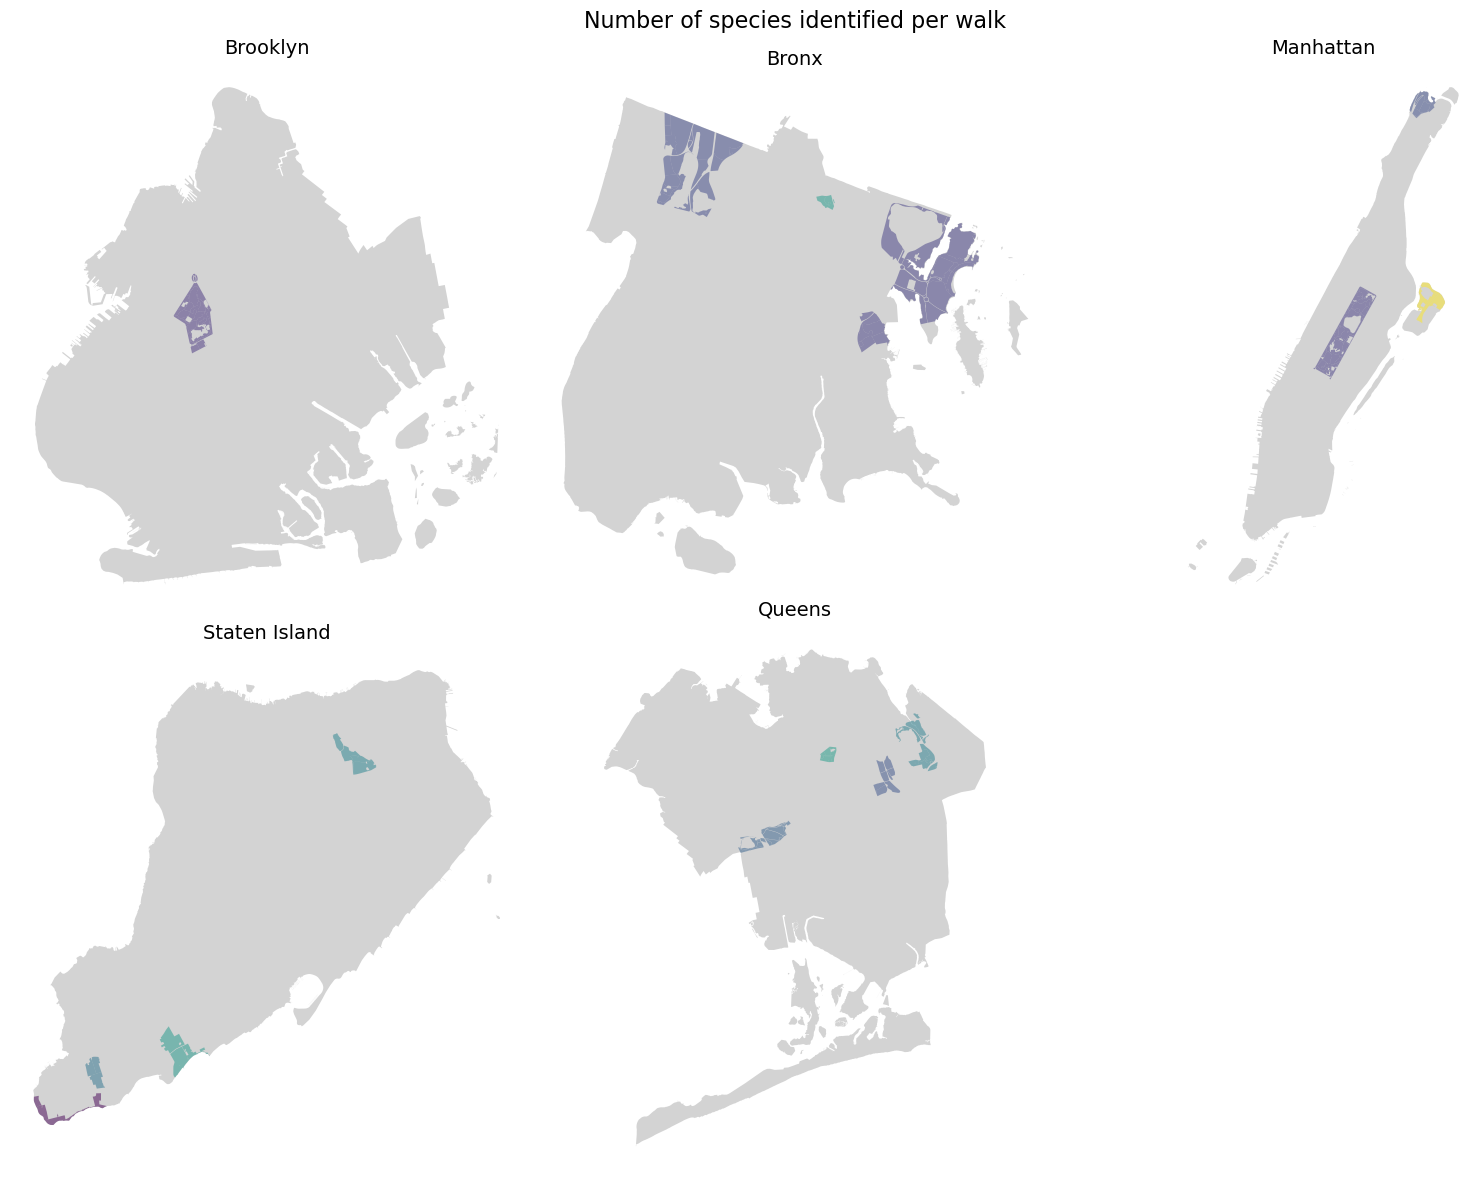

In [20]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesPerWalk', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['SpeciesPerWalk'].min(),
                                                vmax=parks_viz['SpeciesPerWalk'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of species identified per walk', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_species_per_walk.png')
;

''

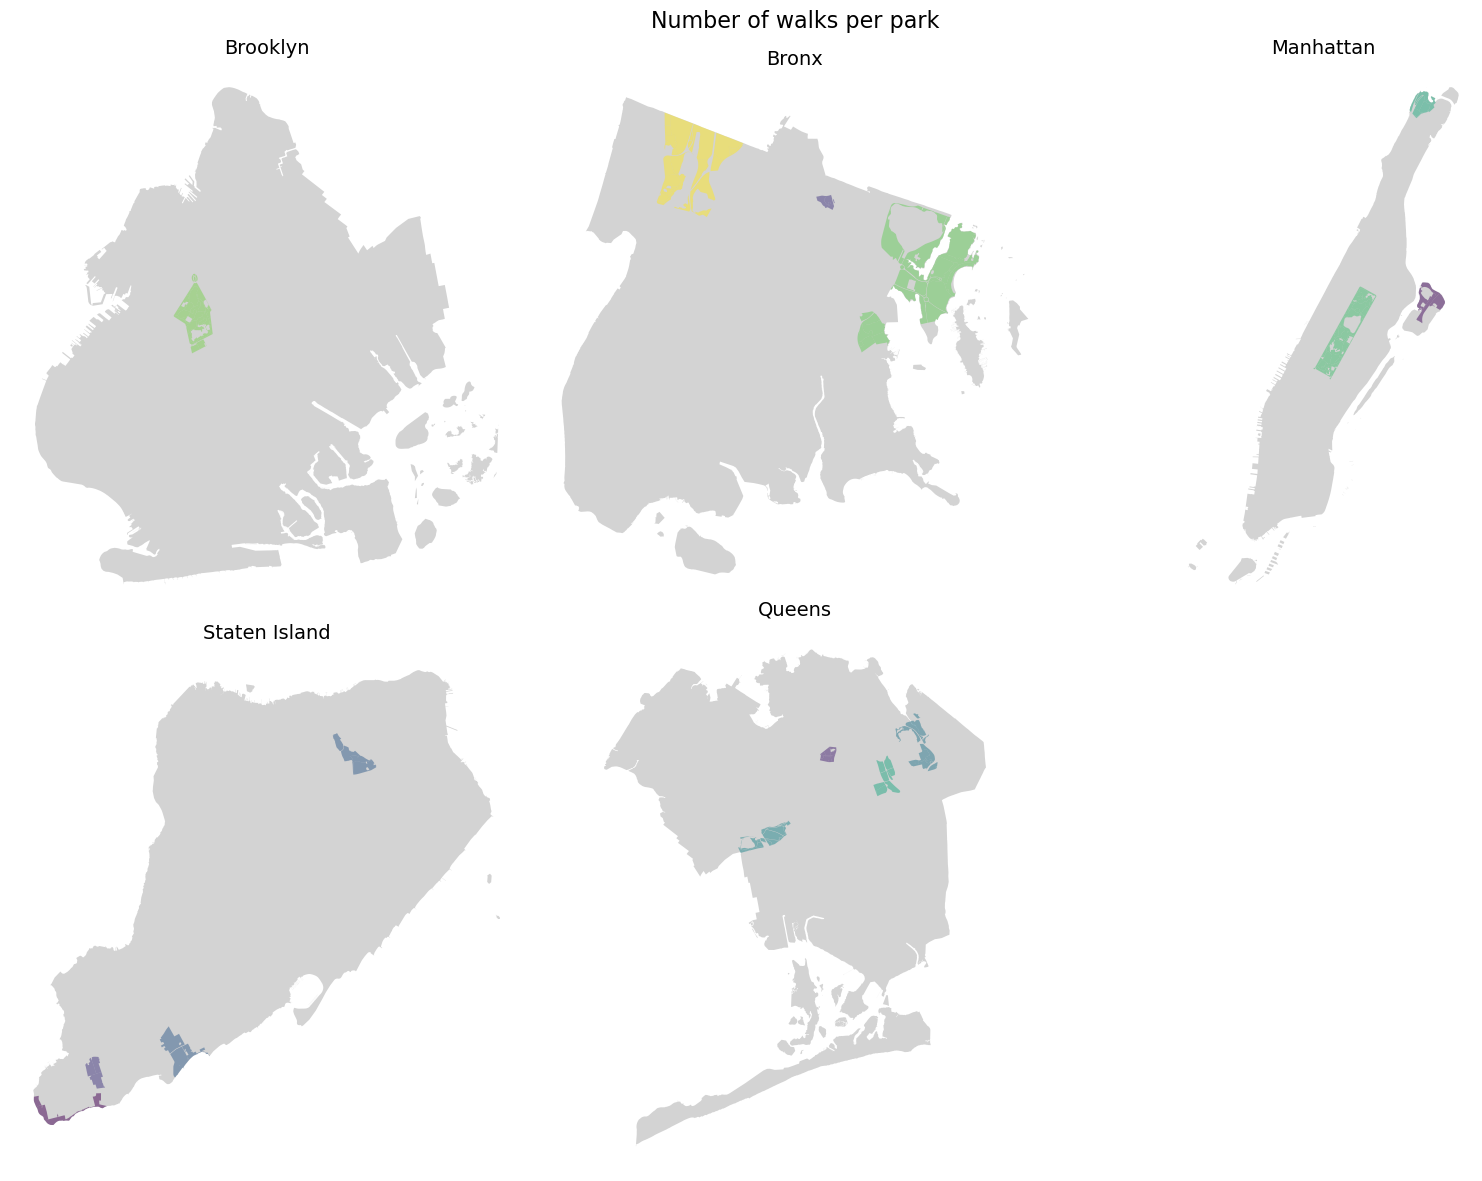

In [21]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='WalkCounts', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['WalkCounts'].min(),
                                                vmax=parks_viz['WalkCounts'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Number of walks per park', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_walks_per_park.png')
;